# EISpac Wrapper for MSSL

## Downloading data:

This will create a folder called data_eis and put the "data" and "head" (data and header) file into that folder.

In [1]:
import eispac
data = 'eis_20140202_102527.data.h5'
a = eispac.download.download_hdf5_data(data)

 + data_eis/eis_20140202_102527.data.h5 exists, skipping download
 + data_eis/eis_20140202_102527.head.h5 exists, skipping download


## Main code for getting data products of EIS

The black box that can just be run.

Description: I have included everything into a class, this enables us to define an object, and allow different functions to perform on top of the object.

In [2]:
# a lot of information are gathered through Will Barnes Hinode-14 sunpy tutorial - It will be a good manor to cite the sunpy team

from pathlib import Path
import eispac
import sunpy
from matplotlib import colors
import matplotlib.pyplot as plt
from datetime import datetime
from astropy.visualization import ImageNormalize, quantity_support


def load_plotting_routine():
    fig = plt.figure()
    fig.set_dpi(300)
    BIGGER_SIZE=9
    SMALLER_SIZE=8
    plt.rc('font', size=BIGGER_SIZE)  # controls default text sizes
    plt.rc('axes', titlesize=BIGGER_SIZE)  # fontsize of the axes title
    plt.rc('axes', labelsize=SMALLER_SIZE)  # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALLER_SIZE)  # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALLER_SIZE)  # fontsize of the tick labels
    plt.rc('legend', fontsize=BIGGER_SIZE)  # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def load_axes_labels():
    plt.xlabel('x (arcsec)')
    plt.ylabel('y (arcsec)')


class asheis:
    
    def __init__(self, filename):
        self.filename = filename
        self.dict = {
            "fe_12_195" : ["fe_12_195_119.2c.template.h5",0],
            "ar_14_194" : ["ar_14_194_396.6c.template.h5",5],
            "ca_14_193" : ["ar_14_194_396.6c.template.h5",1],
            "si_10_258" : ["si_10_258_375.1c.template.h5",0],
            "s_10_264" : ["s__10_264_233.1c.template.h5",0],
            "fe_13_202" : ["fe_13_202_044.1c.template.h5",0],
            "fe_13_203" : ["fe_13_203_826.2c.template.h5",1]
        }
        
    def fit_data(self,line,product):
        template_name=self.dict[f'{line}'][0]
        # print(self.filename.replace("data.h5",template_name))
        path = Path(f'{self.filename}'.replace("data.h5",template_name).replace(".template",f"-{self.dict[f'{line}'][1]}.fit"))
        if path.is_file() == False:
            template = eispac.read_template(eispac.data.get_fit_template_filepath(template_name))
            cube = eispac.read_cube(self.filename, window=template.central_wave)
            fit_res = eispac.fit_spectra(cube, template, ncpu='max')
            save_filepaths = eispac.save_fit(fit_res)
        else:
            fit_res=eispac.read_fit(path)

        fit_res.fit[f'{product}'] = fit_res.shift2wave(fit_res.fit[f'{product}'],wave=195.119)
        return fit_res
    
    def directory_setup(self, amap):
        date = amap.date.strftime("%Y_%m_%d__%H_%M_%S")
        Path(f'fitted_data/fits/').mkdir(parents=True, exist_ok=True)
        Path(f'fitted_data/{amap.measurement.lower().split()[-1]}/').mkdir(parents=True, exist_ok=True)
        amap.save(f"fitted_data/fits/eis_{date}_{'_'.join(amap.measurement.lower().split())}.fits", overwrite=True)
        return date
    
    def plot_map(self, date, amap, colorbar=False, savefig=True):
        load_plotting_routine()
        amap.plot()
        if colorbar==True: plt.colorbar() 
        load_axes_labels()
        # plt.savefig(f'{date}/eis_{m.measurement.lower().replace(" ","_").replace(".","_")}.png')
        if savefig==True: plt.savefig(f'fitted_data/{amap.measurement.lower().split()[-1]}/eis_{date}_{amap.measurement.lower().replace(" ","_").replace(".","_")}.png')
        # plt.savefig(f'fitted_data/{amap.measurement.lower().split()[-1]}/eis_{date}_{amap.measurement.lower().replace(" ","_").replace(".","_")}.png')

    def get_intensity(self, line):
        fit_res = self.fit_data(line,'int') # Get fitdata
        m = fit_res.get_map(self.dict[f'{line}'][1],measurement='intensity') # From fitdata get map
        date = self.directory_setup(m) # Creating directories
        self.plot_map(date, m) # Plot maps
        
    def get_velocity(self, line, vmin=-10,vmax=10):
        fit_res = self.fit_data(line,'vel')
        m = fit_res.get_map(component = self.dict[f'{line}'][1],measurement='velocity')
        date = self.directory_setup(m)
        m.plot_settings['norm'] = ImageNormalize(vmin=vmin,vmax=vmax) # adjusting the velocity saturation
        self.plot_map(date, m, colorbar=True)
        
    def get_width(self, line):
        fit_res = self.fit_data(line,'vel')
        m = fit_res.get_map(component = self.dict[f'{line}'][1],measurement='width')
        date = self.directory_setup(m)
        self.plot_map(date, m, colorbar=True)

    def get_composition(self, linepair, vmin=0,vmax=4):
        if linepair == "SiS":
            lines=['si_10_258','s_10_264','Si X-S X 1']
        # elif linepair == "CaAr":
        #     lines=['ca_14_193','ar_14_194','Ca XIV-Ar XIV 1'] 
        else:
            print('No line database can be found. Add your line in code.')
        
        template_names=[self.dict[lines[0]][0],self.dict[lines[1]][0]]
        templates = [eispac.read_template(eispac.data.get_fit_template_filepath(t)) for t in template_names]
        for t in templates:
            cube = eispac.read_cube(self.filename, window=t.central_wave)
            fit_res = eispac.fit_spectra(cube, t, ncpu='max')
            fit_res.fit['int'] = fit_res.shift2wave(fit_res.fit['int'],wave=195.119)
            m = fit_res.get_map(component = self.dict[lines[0]][1], measurement='intensity')
            date = m.date.strftime("%Y_%m_%d__%H_%M_%S")
            # Path(f'{date}/fitted_data/').mkdir(parents=True, exist_ok=True)
            # m.save(f"{date}/fitted_data/eis_{'_'.join(m.measurement.lower().split())}.fits", overwrite=True)
            Path(f'fitted_data/fits/').mkdir(parents=True, exist_ok=True)
            Path(f'fitted_data/sis_composition/').mkdir(parents=True, exist_ok=True)
            m.save(f"fitted_data/fits/eis_{date}_{'_'.join(m.measurement.lower().split())}.fits", overwrite=True)
            lines.append(f"eis_{date}_{'_'.join(m.measurement.lower().split())}.fits")
        m_Si = sunpy.map.Map(f'fitted_data/fits/{lines[-2]}')
        m_S = sunpy.map.Map(f'fitted_data/fits/{lines[-1]}')
        m_SiS = m_Si
        m_SiS.meta['line_id'] = lines[2]
        m_SiS.save(f"fitted_data/fits/eis_{'_'.join(m_SiS.measurement.lower().split())}.fits", overwrite=True)
        m_SiS = sunpy.map.Map(m_Si.data/m_S.data, m_Si.meta)
        # m_SiS.peek(vmax=4,cmap='RdYlBu')
        load_plotting_routine()
        m_SiS.plot(vmin=vmin, vmax=vmax, norm=colors.Normalize(), cmap='CMRmap')
        # plt.figure()
        plt.colorbar()
        load_axes_labels()
        # plt.savefig(f'{date}/eis_{m_SiS.measurement.lower().replace(" ","_").replace(".","_")}.png')
        plt.savefig(f'fitted_data/sis_composition/eis_{date}_{m_SiS.measurement.lower().replace(" ","_").replace(".","_")}.png')


## Getting data products

In order to get the maps using what we defined above, do the following - get_intensity, get_velocity and get_width.

Then we define the specific line that we want to use. For example, FeXII 195.12 is called 'fe_12_195'.

For getting Si/S composition maps, you can do file.get_composition('SiS').

Reading fit result from, 
   data_eis/eis_20140202_102527.fe_12_195_119.2c-0.fit.h5
INFO: uncertainty should have attribute uncertainty_type. [astropy.nddata.nddata]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


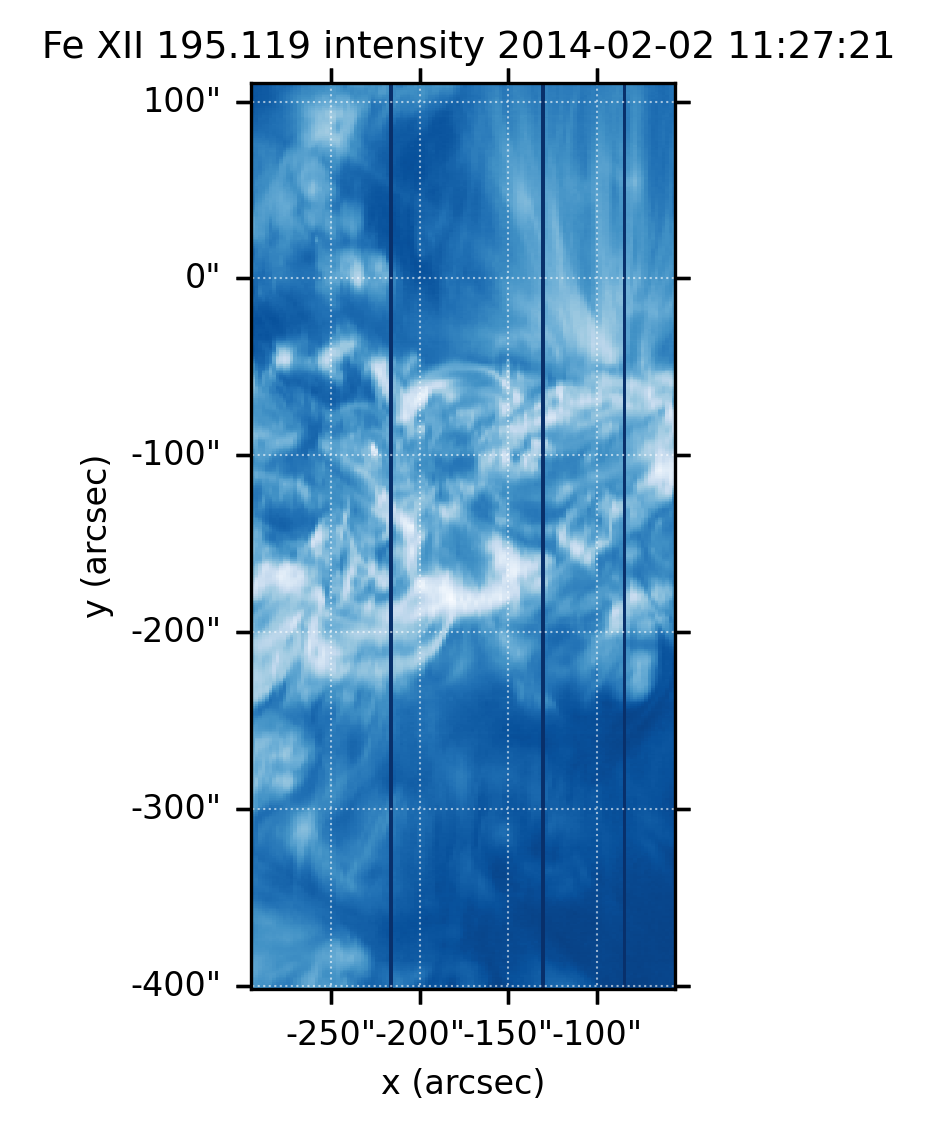

In [3]:
from asheis import asheis
file = asheis(f'data_eis/{data}')
file.get_intensity('fe_12_195')

In [8]:
file.get_velocity('fe_12_195')

Data file,
   /Users/ato/scripts/python_code/asheis/data_eis/eis_20211105_054835.data.h5
Header file,
   /Users/ato/scripts/python_code/asheis/data_eis/eis_20211105_054835.head.h5
Found a wavelength 195.11 [Angstroms] in window 8
INFO: uncertainty should have attribute uncertainty_type. [astropy.nddata.nddata]
 + computing fits for 21 exposures, each with 512 spectra
 + running mpfit on 8 cores (of 8)


Process ForkPoolWorker-15:
Process ForkPoolWorker-16:
Process ForkPoolWorker-13:
Process ForkPoolWorker-12:
Process ForkPoolWorker-11:
Process ForkPoolWorker-9:
Process ForkPoolWorker-10:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/pool.py", line 121, in worker
    result = (True, func(*args, **kwds))
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/pool.py", line 121, in worker
    result = (True, func(*args, *

KeyboardInterrupt: 

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/ato/anaconda3/lib/python3.7/site-packages/eispac/core/mpfit.py", line 1225, in __init__
    ulim1 = ulim * (1 - sgnu * machep) - (ulim == 0) * machep
  File "/Users/ato/anaconda3/lib/python3.7/site-packages/eispac/core/mpfit.py", line 2190, in tie
    exec(cmd)
KeyboardInterrupt
  File "<string>", line 1, in <module>
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
Traceback (most recent call last):
KeyboardInterrupt
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/proce

  File "<string>", line 1, in <module>
  File "/Users/ato/anaconda3/lib/python3.7/site-packages/eispac/core/fit_spectra.py", line 144, in fit_with_mpfit
    maxiter=2000, quiet=1)
KeyboardInterrupt
  File "/Users/ato/anaconda3/lib/python3.7/site-packages/eispac/core/mpfit.py", line 1076, in __init__
    whlpeg = (numpy.nonzero(qllim & (x == llim)))[0]
KeyboardInterrupt


In [ ]:
file.get_width('fe_12_195')

Data file,
   /Users/atm2/python_scripts/asheis/data_eis/eis_20211105_054835.data.h5
Header file,
   /Users/atm2/python_scripts/asheis/data_eis/eis_20211105_054835.head.h5
Found a wavelength 258.40 [Angstroms] in window 15
INFO: uncertainty should have attribute uncertainty_type. [astropy.nddata.nddata]
 + computing fits for 21 exposures, each with 512 spectra
 + running mpfit on 8 cores (of 8)
 + working on exposure 015

Finished computing fits!20
   runtime : 0:00:50.584809
   10752 spectra fit without issues
   0 spectra have < 7 good data points
   0 spectra have bad or invalid parameters
INFO: uncertainty should have attribute uncertainty_type. [astropy.nddata.nddata]
Data file,
   /Users/atm2/python_scripts/asheis/data_eis/eis_20211105_054835.data.h5
Header file,
   /Users/atm2/python_scripts/asheis/data_eis/eis_20211105_054835.head.h5
Found a wavelength 264.17 [Angstroms] in window 18
INFO: uncertainty should have attribute uncertainty_type. [astropy.nddata.nddata]
 + computing 

/Users/atm2/python_scripts/asheis/asheis.py:131: RuntimeWarning: invalid value encountered in true_divide
  m_SiS = sunpy.map.Map(m_Si.data/m_S.data, m_Si.meta)
Set MJD-BEG to 59523.242072 from DATE-BEG.
Set MJD-AVG to 59523.244115 from DATE-AVG.
Set MJD-END to 59523.246157 from DATE-END'. [astropy.wcs.wcs]


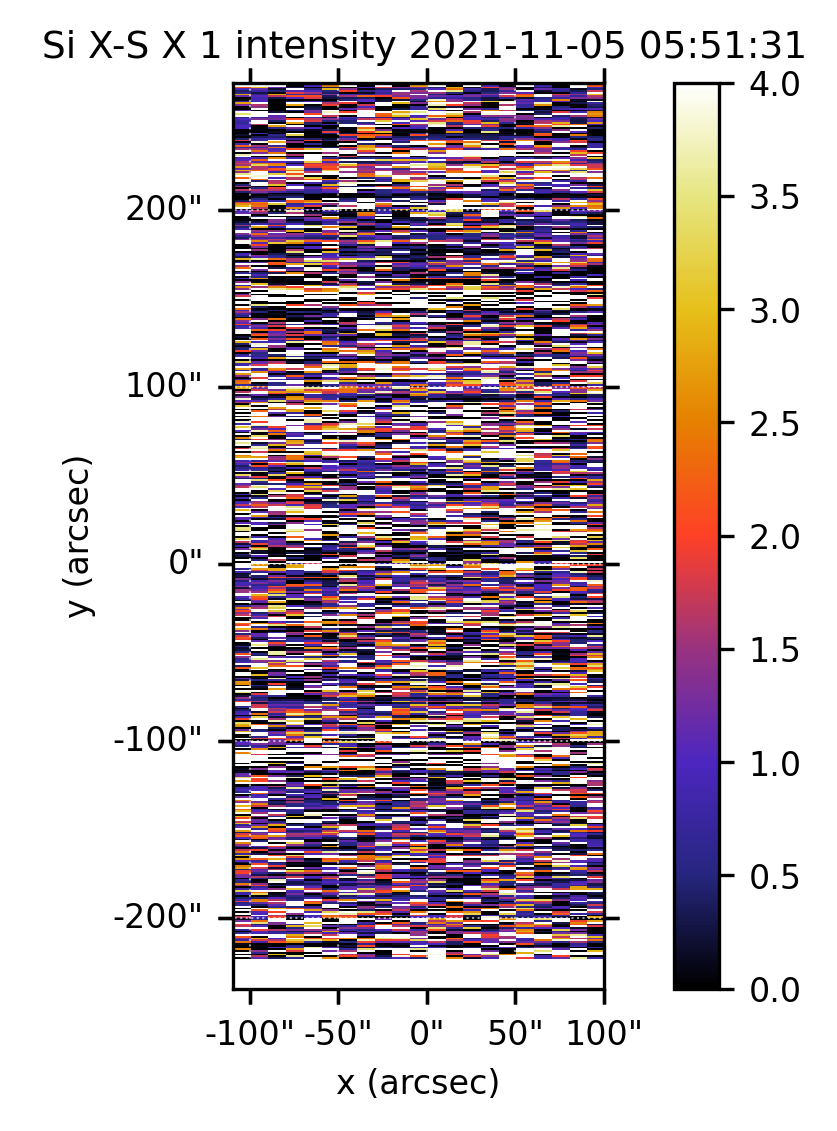

In [19]:
file.get_composition('SiS')

## Looping the fitting process

Sometimes we want to loop the fitting process for say 100 files! We can do the following:

In [1]:
from asheis import asheis
import glob

files = glob.glob('data_eis/*.data.h5')
"""
This (glob.glob) reads everything .data.h5 files in the specfic directory
"""

for i in files:
    """
    Here I used what's a try function. It trys performing the function,
    and if it gives error, skip to the next line
    """
    myfits = asheis(i)
    
    # try:
    myfits.get_intensity('fe_12_195')
    # except:
        # pass

    try:
        myfits.get_velocity('fe_12_195')
    except:
        pass
    
    try:
        myfits.get_width('fe_12_195')
    except:
        pass
    
    try:
        myfits.get_composition('SiS')
    except:
        pass

KeyboardInterrupt: 

## Getting Fit Result

Before we process anything, we have to first readthe fitdata

In [3]:
fit_res=eispac.read_fit('data_eis/eis_20140202_102527.fe_12_195_119.2c-0.fit.h5')

Reading fit result from, 
   data_eis/eis_20140202_102527.fe_12_195_119.2c-0.fit.h5


In [32]:
fit_wave_cube, fit_inten_cube = fit_res.get_fit_profile(component=[0,1])
sum_fit_inten = fit_inten_cube.sum(axis=2)
fit_x, fit_y = fit_res.get_fit_profile(component=0)


In [36]:
fit_inten_cube

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        ...,

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --,